# Imports

In [ ]:
import pandas as pd
import requests
import json
import sqlite3
from google.colab import files
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker



# 1. Data acquisition

## Housing data

In [ ]:
# Converting csv to df
housing_df = pd.read_csv("/content/toronto_remax_listings.csv")

# Preview first few rows
housing_df.head()

/tmp/ipykernel_34857/2028461506.py:2: DtypeWarning: Columns (42) have mixed types. Specify dtype option on import or set low_memory=False.
  housing_df = pd.read_csv("/content/toronto_remax_listings.csv")


,streetAddress,addressLocality,addressRegion,postalCode,latitude,longitude,description,price,priceCurrency,property-beds,...,MLS Area Minor,View,Foundation Details,SqFt Range,Building Area Source,Buyer Agent Designation,Lot Measurement,Lot Size Source,Topography,Current Financing
0,"165 ALGONQUIN BOULEVARD W, Timmins (TS - SW), ...",Timmins (TS - SW),ON,P4N2R6,48.475918,-81.339973,Perfect open concept Starter home with plenty ...,139900.0,CAD,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"415 Wellington ST E, Sault Ste. Marie, ON P6A2M1",Sault Ste. Marie,ON,P6A2M1,46.513422,-84.330831,"Versatile Opportunity! Solid income property, ...",229000.0,CAD,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"248 Prospect AVE, Thunder Bay, ON P7A5L7",Thunder Bay,ON,P7A5L7,48.445437,-89.224910,NEW LISTING! 2-Storey Semi-Detached in College...,379900.0,CAD,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"214 BELANGER AVENUE, Timmins (TS - SW), ON P4N2V9",Timmins (TS - SW),ON,P4N2V9,48.474796,-81.341660,"Conveniently located in a central area, this c...",199000.0,CAD,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"535 MCPHERSON ST, THUNDER BAY, ON P7C2Y5",THUNDER BAY,ON,P7C2Y5,48.392834,-89.228289,Looking for a project with serious potential? ...,129900.0,CAD,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This project uses the Kaggle housing dataset as the main source of listing-level property data.

### 1.1 Scope Check

The project idea is focused on Toronto housing prices, but the downloaded dataset contains listings from across all Canada.

This step filters the data to **Toronto-only**

In [ ]:
# Create a Toronto-only subset for reference
# This is used to see whether Toronto-specific analysis is possible

if "addressLocality" in housing_df.columns:
    housing_toronto = housing_df[
        housing_df["addressLocality"].astype(str).str.contains("Toronto", case=False, na=False)
    ].copy()

    print("Toronto-only subset shape:", housing_toronto.shape)
else:
    housing_toronto = pd.DataFrame()
    print("Toronto filter could not be created because 'addressLocality' is missing.")

Toronto-only subset shape: (6616, 396)


### 1.2 Select the core columns needed for BI analysis

Only the most relevant columns are retained for the next stage of the project.

These include:
- location attributes
- pricing
- beds/baths
- square footage
- property type
- any available listing identifiers

In [ ]:
# Keep only the most useful columns for downstream analysis
selected_cols = [
    "streetAddress",
    "addressLocality",
    "addressRegion",
    "postalCode",
    "latitude",
    "longitude",
    "price",
    "priceCurrency",
    "property-beds",
    "property-baths",
    "Square Footage",
    "Basement",
    "Property Tax",
    "Property Type",
]

# Keep only columns that actually exist in the dataset
available_cols = [col for col in selected_cols if col in housing_toronto.columns]

housing_core = housing_toronto[available_cols].copy()

print("Selected columns:")
print(housing_core.columns.tolist())

housing_core.head()

Selected columns:
['streetAddress', 'addressLocality', 'addressRegion', 'postalCode', 'latitude', 'longitude', 'price', 'priceCurrency', 'property-beds', 'property-baths', 'Square Footage', 'Basement', 'Property Tax', 'Property Type']


,streetAddress,addressLocality,addressRegion,postalCode,latitude,longitude,price,priceCurrency,property-beds,property-baths,Square Footage,Basement,Property Tax,Property Type
1753,"802 - 435 RICHMOND STREET W, Toronto (Waterfro...",Toronto (Waterfront Communities),ON,M5V0N3,43.647652,-79.397018,549999.0,CAD,1.0,1.0,NaN,NaN,"$2,611",Condo
1796,"555 SILVERTHORN AVENUE, Toronto (Keelesdale-Eg...",Toronto (Keelesdale-Eglinton West),ON,M6M3J1,43.690136,-79.467300,800000.0,CAD,2.0,2.0,NaN,"Finished, Separate entrance, N/A","$3,677",Single Family
1809,"21 - 145 LONG BRANCH AVENUE, Toronto (Long Bra...",Toronto (Long Branch),ON,M8W0A9,43.596809,-79.534492,769990.0,CAD,2.0,3.0,NaN,NaN,"$2,555",Condo/Townhome
1816,"1516 - 4725 SHEPPARD AVENUE E, Toronto (Aginco...",Toronto (Agincourt South-Malvern West),ON,M1S5B2,43.790024,-79.254662,614000.0,CAD,3.0,2.0,NaN,NaN,"$1,781",Condo
1817,"114 - 50 SCARBOROUGH GOLF CLUB ROAD, Toronto (...",Toronto (Scarborough Village),ON,M1M3T5,43.744282,-79.209259,590000.0,CAD,3.0,2.0,NaN,NaN,"$1,502",Condo


### 1.3 Missing value summary

In [ ]:
# Review missing values to help the next team member understand data quality
missing_summary = housing_core.isnull().sum().sort_values(ascending=False)
missing_summary

,0
Square Footage,6465
Basement,4743
Property Tax,1339
property-beds,143
property-baths,11
postalCode,1
longitude,0
latitude,0
addressRegion,0
addressLocality,0


## Bank interest rate data collection

### 1.4 API Call

In [ ]:
# Use an official Bank of Canada interest-rate series
# V39079 is commonly used as the overnight rate series
chosen_series = "V39079"

rate_url = f"https://www.bankofcanada.ca/valet/observations/{chosen_series}/json"

rate_response = requests.get(rate_url, timeout=30)
rate_response.raise_for_status()

rate_data = rate_response.json()

print(rate_data.keys())

dict_keys(['terms', 'seriesDetail', 'observations'])


### 1.5 Convert api response to dataframe

In [ ]:
# Extract observations from the API response
observations = rate_data.get("observations", [])

rates_df = pd.DataFrame(observations)

print("Raw rate data shape:", rates_df.shape)
rates_df.head()

Raw rate data shape: (4415, 2)


,d,V39079
0,2009-04-21,{'v': '0.25'}
1,2009-04-22,{'v': '0.25'}
2,2009-04-23,{'v': '0.25'}
3,2009-04-24,{'v': '0.25'}
4,2009-04-27,{'v': '0.25'}


### 1.6 Check interest rate data quality

In [ ]:
# Check missing values for the final interest-rate dataset
print("\nMissing values:")
print(rates_df.isnull().sum())


Missing values:
d         0
V39079    0
dtype: int64


## Save final outputs

In [ ]:
# Save acquisition-stage outputs
housing_core.to_csv("housing_acquired_final.csv", index=False)
rates_df.to_csv("bank_of_canada_interest_rates_final.csv", index=False)

print("Saved: housing_acquired_final.csv")
print("Saved: bank_of_canada_interest_rates_final.csv")

Saved: housing_acquired_final.csv
Saved: bank_of_canada_interest_rates_final.csv


# 2. Data Processing (Cleaning + Storage)

In this step, the Toronto housing dataset is cleaned and prepared for analysis.  
Data collected from different sources may contain missing values, duplicate records, or inconsistent formats.  

The dataset is cleaned by removing duplicates, handling missing values, converting columns into correct formats, and standardizing column names.  

After cleaning, the processed data is stored in a SQLite database to support efficient querying and future visualization using BI tools such as Power BI.

## 2.1 Create copy of dataset


In [ ]:
housing_cleaned = housing_core.copy()

print("Initial Toronto dataset shape:", housing_cleaned.shape)

Initial Toronto dataset shape: (6616, 14)


## 2.2 Standardize column names and values

In [ ]:
housing_cleaned.columns = (
    housing_cleaned.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace("/", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(":", "", regex=False)
)

housing_cleaned['property_tax'] = (
    housing_cleaned['property_tax']
    .astype(str)
    .str.replace(r'[$,]', '', regex=True)     # Remove $ and ,
    .str.split().str[0]                       # Keep only the number, drop '(2024)'
    .replace('nan', np.nan)                   # Put actual NaNs back
    .astype(float)                            # Convert to number
)

print(housing_cleaned.columns.tolist())
print(housing_cleaned.head(10))


['streetaddress', 'addresslocality', 'addressregion', 'postalcode', 'latitude', 'longitude', 'price', 'pricecurrency', 'property_beds', 'property_baths', 'square_footage', 'basement', 'property_tax', 'property_type']
                                          streetaddress  \
1753  802 - 435 RICHMOND STREET W, Toronto (Waterfro...   
1796  555 SILVERTHORN AVENUE, Toronto (Keelesdale-Eg...   
1809  21 - 145 LONG BRANCH AVENUE, Toronto (Long Bra...   
1816  1516 - 4725 SHEPPARD AVENUE E, Toronto (Aginco...   
1817  114 - 50 SCARBOROUGH GOLF CLUB ROAD, Toronto (...   
1824  610 - 501 ADELAIDE STREET W, Toronto (Waterfro...   
1825  TH5 - 85 WOOD STREET, Toronto (Church-Yonge Co...   
1826  3112 - 290 ADELAIDE STREET W, Toronto (Waterfr...   
1827  101 OLD COLONY ROAD, Toronto (St. Andrew-Windf...   
1828  50 WELLESLEY STREET E, Toronto (Church-Yonge C...   

                             addresslocality addressregion postalcode  \
1753        Toronto (Waterfront Communities)            ON  

## 2.3 Remove duplicate rows

In [ ]:
housing_cleaned = housing_cleaned.drop_duplicates()

print("Shape after removing duplicates:", housing_cleaned.shape)

Shape after removing duplicates: (6616, 14)


In [ ]:
housing_cleaned.head()


,streetaddress,addresslocality,addressregion,postalcode,latitude,longitude,price,pricecurrency,property_beds,property_baths,square_footage,basement,property_tax,property_type
1753,"802 - 435 RICHMOND STREET W, Toronto (Waterfro...",Toronto (Waterfront Communities),ON,M5V0N3,43.647652,-79.397018,549999.0,CAD,1.0,1.0,NaN,NaN,2611.0,Condo
1796,"555 SILVERTHORN AVENUE, Toronto (Keelesdale-Eg...",Toronto (Keelesdale-Eglinton West),ON,M6M3J1,43.690136,-79.467300,800000.0,CAD,2.0,2.0,NaN,"Finished, Separate entrance, N/A",3677.0,Single Family
1809,"21 - 145 LONG BRANCH AVENUE, Toronto (Long Bra...",Toronto (Long Branch),ON,M8W0A9,43.596809,-79.534492,769990.0,CAD,2.0,3.0,NaN,NaN,2555.0,Condo/Townhome
1816,"1516 - 4725 SHEPPARD AVENUE E, Toronto (Aginco...",Toronto (Agincourt South-Malvern West),ON,M1S5B2,43.790024,-79.254662,614000.0,CAD,3.0,2.0,NaN,NaN,1781.0,Condo
1817,"114 - 50 SCARBOROUGH GOLF CLUB ROAD, Toronto (...",Toronto (Scarborough Village),ON,M1M3T5,43.744282,-79.209259,590000.0,CAD,3.0,2.0,NaN,NaN,1502.0,Condo


## 2.4 Handle missing values


In [ ]:
# 1. Drop square_footage (97% missing is too high for reliable imputation)
housing_cleaned.drop(columns=['square_footage'], inplace=True)

# 2. Convert basement NaNs to 'None' (assuming missing means absence)
housing_cleaned['basement'] = housing_cleaned['basement'].fillna('None')

# 3. Impute property_tax using the median for each locality
# Localities with no data will fall back to the overall dataset median
housing_cleaned['property_tax'] = housing_cleaned.groupby('addresslocality')['property_tax'].transform(lambda x: x.fillna(x.median()))
housing_cleaned['property_tax'] = housing_cleaned['property_tax'].fillna(housing_cleaned['property_tax'].median())

# 4. Impute beds and baths using the mode for each property type
def impute_mode(series):
    mode = series.mode()
    return series.fillna(mode[0] if not mode.empty else np.nan)

housing_cleaned['property_beds'] = housing_cleaned.groupby('property_type')['property_beds'].transform(impute_mode)
housing_cleaned['property_baths'] = housing_cleaned.groupby('property_type')['property_baths'].transform(impute_mode)

# 5. Drop the single missing postalcode
housing_cleaned.dropna(subset=['postalcode'], inplace=True)

# 6. Drop missing values for beds and baths after imputing
housing_cleaned.dropna(subset=['property_beds', 'property_baths'], inplace=True)

# Verify the results
print(housing_cleaned.isnull().sum())

streetaddress      0
addresslocality    0
addressregion      0
postalcode         0
latitude           0
longitude          0
price              0
pricecurrency      0
property_beds      0
property_baths     0
basement           0
property_tax       0
property_type      0
dtype: int64


## 2.5 Store cleaned dataset in SQLite database


In [ ]:
conn = sqlite3.connect("toronto_housing_cleaned.db")

housing_cleaned.to_sql(
    "housing_cleaned",
    conn,
    if_exists="replace",
    index=False
)

print("Toronto-only dataset stored successfully.")


Toronto-only dataset stored successfully.


## 2.6 Verify stored data

In [ ]:
check_df = pd.read_sql(
    "SELECT * FROM housing_cleaned LIMIT 10",
    conn
)

check_df

,streetaddress,addresslocality,addressregion,postalcode,latitude,longitude,price,pricecurrency,property_beds,property_baths,basement,property_tax,property_type
0,"802 - 435 RICHMOND STREET W, Toronto (Waterfro...",Toronto (Waterfront Communities),ON,M5V0N3,43.647652,-79.397018,549999.0,CAD,1.0,1.0,None,2611.0,Condo
1,"555 SILVERTHORN AVENUE, Toronto (Keelesdale-Eg...",Toronto (Keelesdale-Eglinton West),ON,M6M3J1,43.690136,-79.467300,800000.0,CAD,2.0,2.0,"Finished, Separate entrance, N/A",3677.0,Single Family
2,"21 - 145 LONG BRANCH AVENUE, Toronto (Long Bra...",Toronto (Long Branch),ON,M8W0A9,43.596809,-79.534492,769990.0,CAD,2.0,3.0,None,2555.0,Condo/Townhome
3,"1516 - 4725 SHEPPARD AVENUE E, Toronto (Aginco...",Toronto (Agincourt South-Malvern West),ON,M1S5B2,43.790024,-79.254662,614000.0,CAD,3.0,2.0,None,1781.0,Condo
4,"114 - 50 SCARBOROUGH GOLF CLUB ROAD, Toronto (...",Toronto (Scarborough Village),ON,M1M3T5,43.744282,-79.209259,590000.0,CAD,3.0,2.0,None,1502.0,Condo
5,"610 - 501 ADELAIDE STREET W, Toronto (Waterfro...",Toronto (Waterfront Communities),ON,M5V0R3,43.645405,-79.401413,539900.0,CAD,1.0,1.0,None,2174.0,Condo
6,"TH5 - 85 WOOD STREET, Toronto (Church-Yonge Co...",Toronto (Church-Yonge Corridor),ON,M4Y0E8,43.662723,-79.379440,1449000.0,CAD,4.0,3.0,None,8161.0,Condo
7,"3112 - 290 ADELAIDE STREET W, Toronto (Waterfr...",Toronto (Waterfront Communities),ON,M5V0P3,43.647846,-79.390953,534900.0,CAD,1.0,1.0,None,2554.0,Condo
8,"101 OLD COLONY ROAD, Toronto (St. Andrew-Windf...",Toronto (St. Andrew-Windfields),ON,M2L2K3,43.758757,-79.375035,17500000.0,CAD,6.0,10.0,"Finished, Walk-up, N/A",61923.0,Single Family
9,"50 WELLESLEY STREET E, Toronto (Church-Yonge C...",Toronto (Church-Yonge Corridor),ON,M4Y1G2,43.665661,-79.382606,95000.0,CAD,0.0,0.0,None,3004.0,Condo


### Section Summary

The dataset was successfully cleaned by removing duplicate records, handling missing values, and converting important columns into numeric format.  

Finally, the cleaned dataset was stored in a SQLite database for future analysis and visualization.

## 3. Data Analysis & Visualization

## 3.1 Location Analysis

This section analyzes Toronto housing prices by Forward Sortation Area (FSA), which is derived from the first three characters of the postal code. The FSA is used as a proxy for neighborhood to identify which areas have the highest median listing prices and how prices vary across different parts of the city.

In [ ]:
# Create FSA column (first 3 digits of postal code) for neighborhood analysis
housing_cleaned["fsa"] = housing_cleaned["postalcode"].str[:3]
housing_cleaned[["postalcode","fsa"]].head()

,postalcode,fsa
1753,M5V0N3,M5V
1796,M6M3J1,M6M
1809,M8W0A9,M8W
1816,M1S5B2,M1S
1817,M1M3T5,M1M


In [ ]:
# caluclate median price by FSA
# group the data by FSA
# median is used instead of average to reduce the effect of very expensive
# count number of listings in that area
fsa_analysis = (
    housing_cleaned
    .groupby("fsa")["price"]
    .agg(["median", "count"])
    .sort_values("median", ascending=False)
)

#show top 10 most expensive FSAs
fsa_analysis.head(10)

,median,count
fsa,,
M2L,4995000.0,53
M9Y,3998000.0,1
M3B,3724500.0,44
M2P,3690000.0,35
M4N,3541500.0,26
M5N,2399000.0,29
M5M,2248000.0,45
L6P,2224949.5,36
A1A,1998000.0,5


In [ ]:
# create a summary table by FSA
# median = typical price in the area
# count = number of listings in the area

fsa_analysis = (
    housing_cleaned
    .groupby("fsa")["price"]
    .agg(["median", "count"])
)

# keep only FSAs with at least 5 listings
reliable_fsa = (
    fsa_analysis[fsa_analysis["count"] >= 5]
    .sort_values("median", ascending=False)
)

#show top 10 reliable FSAs
reliable_fsa.head(10)

,median,count
fsa,,
M2L,4995000.0,53
M3B,3724500.0,44
M2P,3690000.0,35
M4N,3541500.0,26
M5N,2399000.0,29
M5M,2248000.0,45
L6P,2224949.5,36
A1A,1998000.0,5
M4V,1995000.0,63


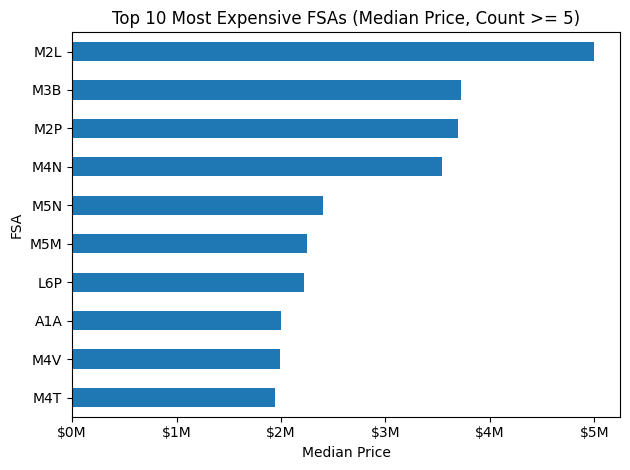

In [ ]:
# create bar chart for Top 10 reliable FSAs (median price)
plt.figure()
reliable_fsa["median"].head(10).iloc[::-1].plot(kind="barh")

plt.title("Top 10 Most Expensive FSAs (Median Price, Count >= 5)")
plt.xlabel("Median Price")
plt.ylabel("FSA")

# format x-axis to show values in millions
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${int(x/1e6)}M'))

plt.tight_layout()
plt.show()

This chart shows the Top 10 most expensive FSAs (Forward Sortation Area) in Toronto based on median listing price. Median values are used to reduce the impact of outliers, and only areas with at least 5 listings are included to ensure reliability.

M2L is the most expensive FSA with a median price of ~$5M, followed by M3B and M2P at approximately $3.7M. The reamining FSAs range between $2M and $3.5M, highlighting significant price variation across different parts of the city.

In [ ]:
# remove Brampton listings from housing_cleaned
# Brampton falls outside the Toronto market

housing_cleaned = housing_cleaned[
    ~housing_cleaned["addresslocality"].str.contains("Brampton", case=False, na=False)
]

print("Records after removing Brampton:", len(housing_cleaned))

Records after removing Brampton: 6577


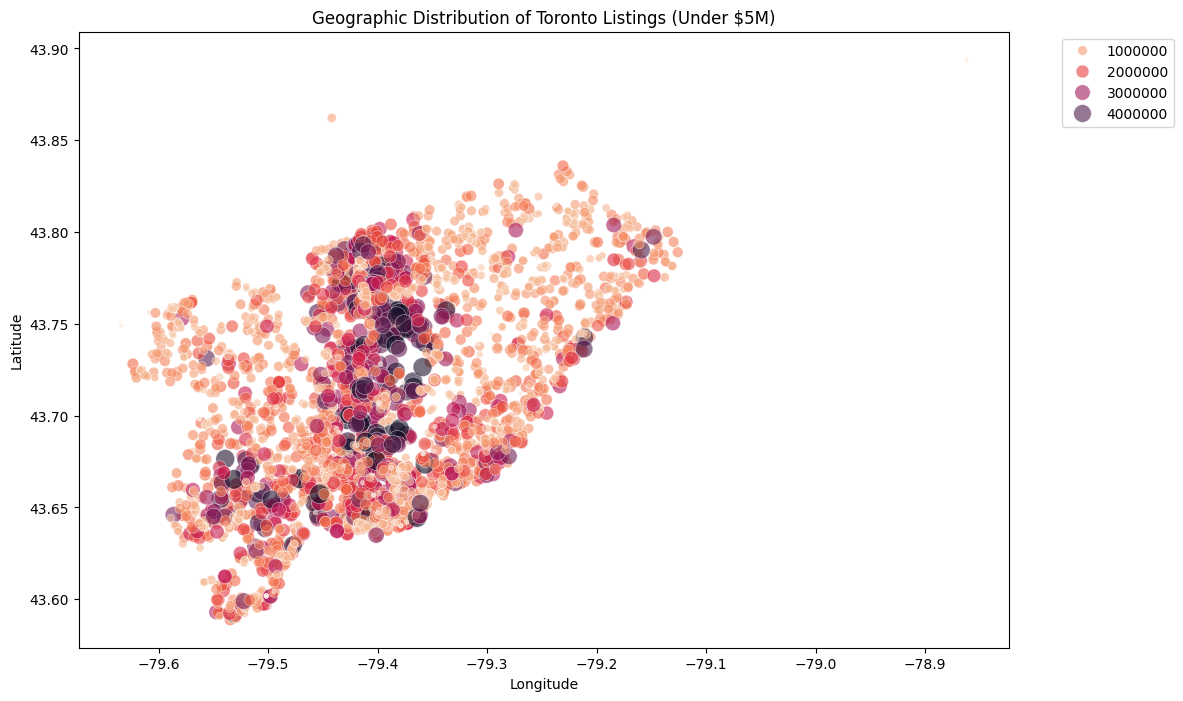

In [ ]:
# Geographic map of listings with Price information

# Create figure with larger size for better visibility
plt.figure(figsize=(12, 8))

# use Longitude for X and Latitude for Y
# hue = color base on price (higher price, darker color)
# palette="rocket_r" goes from light to dark
# filter to listings under $5M to reduce extreme outliers and improve readability

scatter = sns.scatterplot(
    x='longitude',
    y='latitude',
    hue='price',
    size='price',
    sizes=(10, 200), # control min and max dot size
    data=housing_cleaned[housing_cleaned['price'] < 5000000],
    palette="rocket_r",
    alpha=0.6   # transparency to help show density
)

# add title and axis labels
plt.title("Geographic Distribution of Toronto Listings (Under $5M)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# legend
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

This map visualizes the spatial distribution of housing listings across Toronto using latitude and longitude coordinates. Each point represents a property, with color and size indicating the listing price. Lighter colors represent lower-priced properties, while darker and larger points indicate higher-value listings.

The distribution of points follows the geographic shape of the city, highlighting where listings are concentrated. Higher priced properties tend to cluster in specific central and northern areas, while more affordable listings are more widely distributed. This visualization provides a clear view of how property values vary across different locations in Toronto.

## 3.2 Market Composition

### Price Distribution

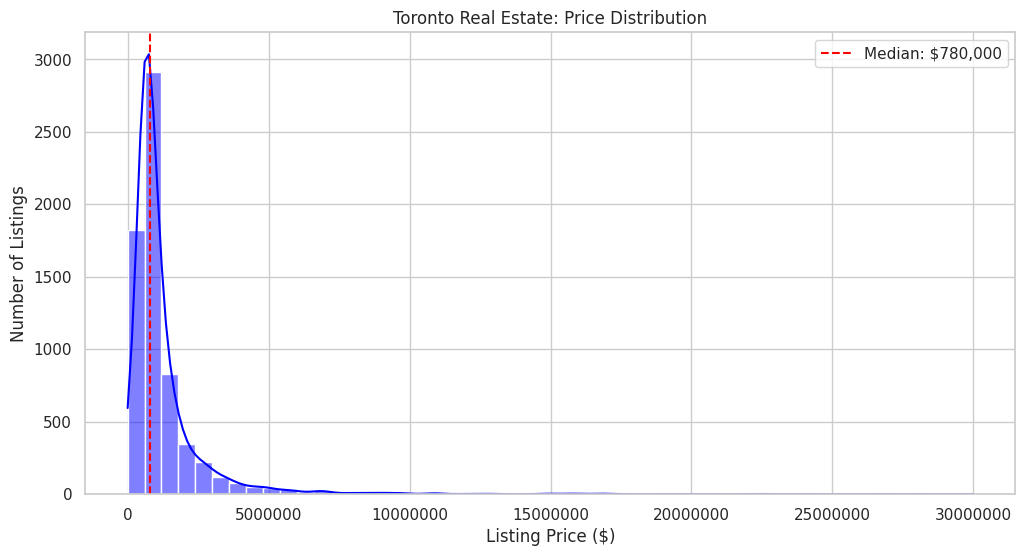

In [ ]:
# Price Distribution (Histogram)

# Set style
sns.set_theme(style="whitegrid")

# Calculate median
overall_median = housing_cleaned["price"].median()

plt.figure(figsize=(12, 6))

# Histogram (blue bars)
sns.histplot(
    housing_cleaned["price"],
    bins=50,
    kde=True,
    color="blue"   # bars will be blue
)

# Median line (red dashed)
plt.axvline(
    overall_median,
    color="red",
    linestyle="--",
    label=f"Median: ${overall_median:,.0f}"
)

plt.title("Toronto Real Estate: Price Distribution")
plt.xlabel("Listing Price ($)")
plt.ylabel("Number of Listings")

plt.legend()

plt.ticklabel_format(style="plain", axis="x")

plt.show()

The histogram shows the housing price distribution across Toronto listings.

The distribution is right-skewed, with most listings concentrated in the lower price range (approximately 500,000 to 1.5M), while a small number of high-value properties extend the upper range beyond $30M.

The long right tail suggests that the mean price is significantly influenced by high-value properties. As a result, the median provides a more reliable measure of the listing price.

Most listings are clustered within a lower and more affordable price range, showing that most homes fall within a relatively narrow band. In contrast, higher-priced luxury properties make up only a small portion of the overall market.

### Property Type Analysis

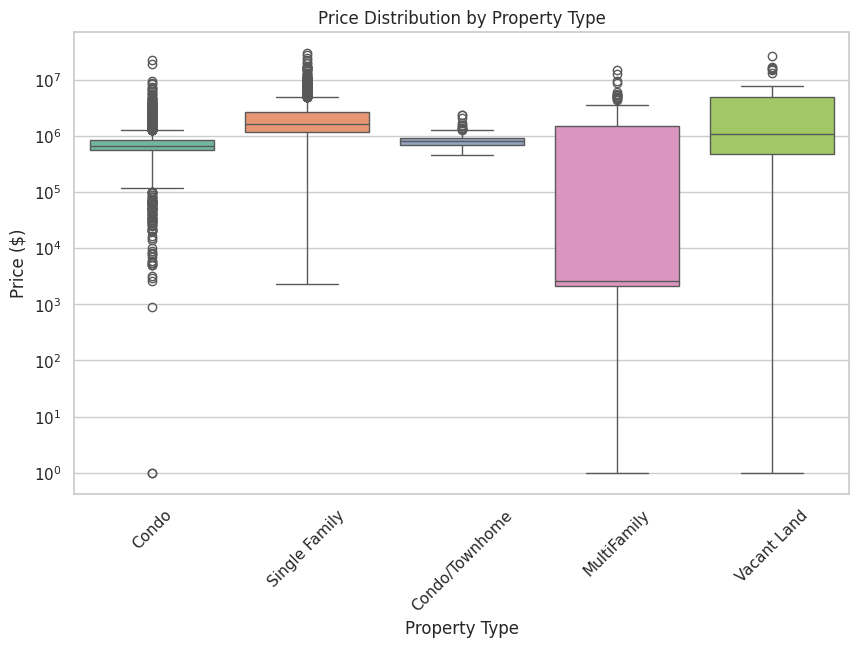

In [ ]:
# Property type vs price (Boxplot)

# create a figure with a wider size for better readability
plt.figure(figsize=(10, 6))

# Create a boxplot
# x-axis is property type (condo, house, townhouse)'
# y-axis is price

sns.boxplot(
    x="property_type",
    y="price",
    data=housing_cleaned,
    hue="property_type",
    palette="Set2",
    legend=False
)

# add title and labels
plt.title("Price Distribution by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Price ($)")

# if x-axis labels overlap, rotate them
plt.xticks(rotation=45)

plt.yscale('log')

plt.show()

This boxplot compares price distributions across property types using a logarithmic scale, which allows both lower priced and high-value properties to be visualized together, despite the large price differences across the dataset.

Among the property types, single-family homes have the highest median price, while condos are generally more affordable and show a tighter price range. Condo/townhome properties appear to have the most consistent pricing, with a narrow distribution.

Multifamily properties display a much wider range of prices, which likely reflects the diversity within this category, from smaller units to larger income-generating buildings. As a result, this group is less consistent and harder to interpret as a single segment.

Several categories show outliers with values as low as $1, which are likely data quality issues rather than actual market transactions and should be interpreted with caution.

Overall, single-family homes represent the highest-value segment, while condos dominate in terms of volume and affordability.

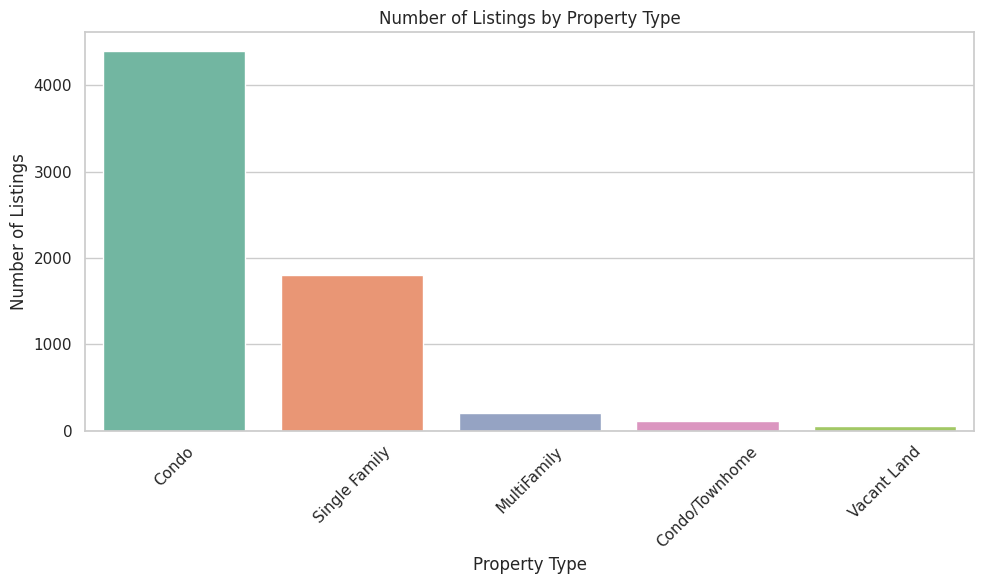

In [ ]:
# Property Type Count (Bar Chart)
# shows which property types are most common in the market

type_counts = housing_cleaned["property_type"].value_counts().reset_index()
type_counts.columns = ["property_type", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(
    x="property_type",
    y="count",
    data=type_counts,
    hue="property_type",
    palette="Set2",
    legend=False
)

plt.title("Number of Listings by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

When looking at both charts, condos clearly dominate the Toronto market, with over 4,300 listings, which more than double the next category. However, the price distribution chart shows that condos are generally on the lower end of the price range.

Single- family homes are the second most common property type, with about 1850 listings, but they have the highest median prices overall. Meanwhile, multifamily homes, condo/townhomes, and vacant land represent much smaller market segments with relatively few listings.

This suggests that Toronto's market is driven by condo inventory, while higher property values are concentrated in single-family homes.

## 3.3 Property Configuration

This section analyzes the relationship between bedrooms and bathrooms to identify the most common home layouts in the Toronto market.

In [ ]:
housing_cleaned[["property_beds", "property_baths", "price"]].head()

,property_beds,property_baths,price
1753,1.0,1.0,549999.0
1796,2.0,2.0,800000.0
1809,2.0,3.0,769990.0
1816,3.0,2.0,614000.0
1817,3.0,2.0,590000.0


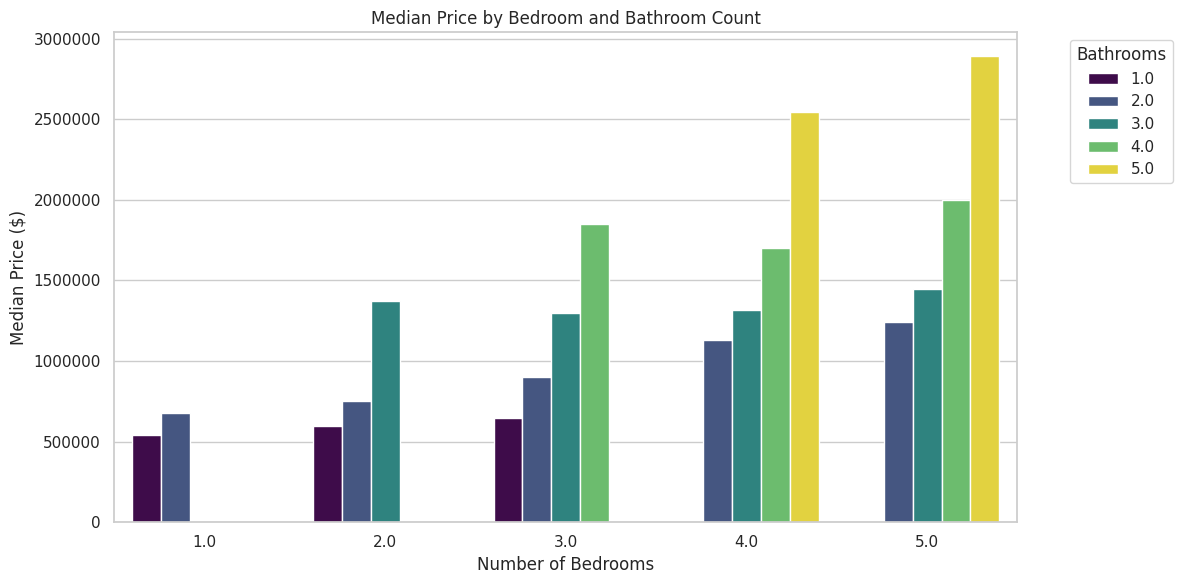

In [ ]:
# Median Price by Bedroom and Bathroom Count

# count how many listings exist for each beds/baths combination
combo_counts = housing_cleaned.groupby(
    ["property_beds", "property_baths"]
).size().reset_index(name="count")

# keep only common configurations (1 to 5 bedrooms / bathrooms)
# this removes unusual listings so the chart is easier to read
layout_data = housing_cleaned[
    (housing_cleaned["property_beds"].between(1, 5)) &
    (housing_cleaned["property_baths"].between(1, 5))
]

# add count info to each row
layout_data = layout_data.merge(
    combo_counts,
    on=["property_beds", "property_baths"]
)

# keep only combinations with enough listings (>= 20)
layout_data = layout_data[layout_data["count"] >= 20]

plt.figure(figsize=(12, 6))

# Create bar chart:
# x is number of bedrooms
# y is median price
# hue is number of bathrooms
sns.barplot(
    x="property_beds",
    y="price",
    hue="property_baths",
    data=layout_data,
    estimator=np.median,
    errorbar=None,
    palette="viridis"
)

plt.title("Median Price by Bedroom and Bathroom Count")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Median Price ($)")
plt.legend(title="Bathrooms", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

This chart shows how different combinations of bedrooms and bathrooms relate to property prices. In general, homes with more bedrooms tend to have higher median prices, and having more bathrooms also adds value. However, these two features often increase together, so the price differences are likely influenced by overall property size and quality rather than a single factor alone.

There are also some noticeable exceptions. For example, certain configurations with fewer bedrooms but more bathrooms, such as 3-bedroom homes with 4 bathrooms, can have higher median prices (~$1.85M) than larger homes with 4 bedrooms and 4 bathrooms (~$1.75M). This may be due to factors not directly captured in the dataset, such as property quality, upgrades, or location.

Overall, the chart highlights that property value is influenced by a combination of layout, quality, and external factors, rather than just the number of rooms.

## 3.4 Feature Drivers


### Correlation Analysis (Heatmap)

In [ ]:
# filter out unrealistic property tax values for this section only
# housing_cleaned remains unchanged for other sections

tax_cleaned = housing_cleaned[
    (housing_cleaned["property_tax"] >= 500) &
    (housing_cleaned["property_tax"] <= 30000)
]

print("Records kept:", len(tax_cleaned))
print("Records removed:", len(housing_cleaned) - len(tax_cleaned))

Records kept: 6459
Records removed: 118


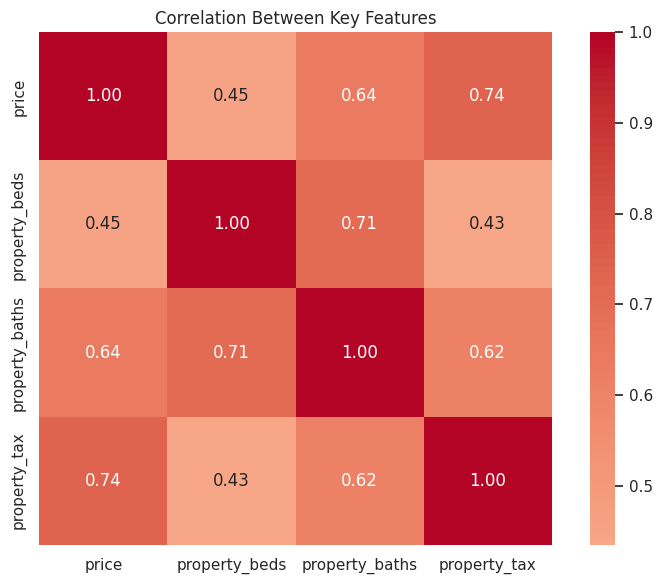

In [ ]:
# Correlation Heatmap
# shows relationships between numeric features

corr_data = tax_cleaned[[
    "price",
    "property_beds",
    "property_baths",
    "property_tax"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Between Key Features")
plt.tight_layout()
plt.show()

This heatmap shows the relationship between price and key features such as bedrooms, bathrooms, and property tax. Among these variables, property tax has the strongest relationship with price (0.74), followed by the number of bathrooms (0.64), while the number of bedrooms shows a weaker relationship (0.46).

This suggests that factors reflecting overall property value and quality, such as bathroom count and assessed tax, are more closely associated with price than bedroom count alone.

In addition, the strong correlation between bedrooms and bathrooms (0.71) indicates that these features tend to increase together. This supports the earlier findings in the property configuration analysis, where both variables were shown to influence price but are closely linked to overall property size.


### Price vs Property Tax

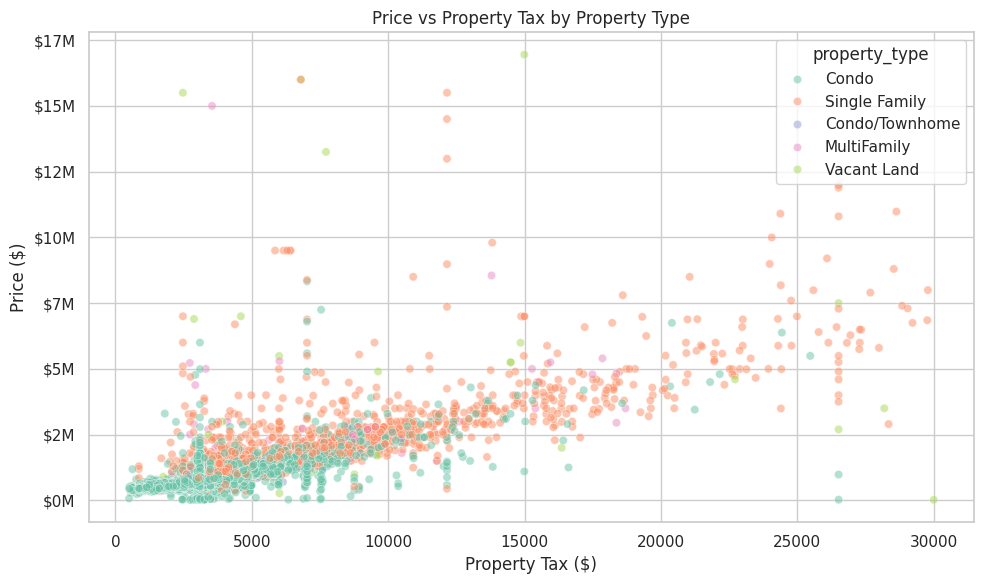

In [ ]:
# validates relationship between tax and price

# filter out corrupt price values
scatter_data = tax_cleaned[tax_cleaned["price"] > 10000]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="property_tax",
    y="price",
    data=scatter_data,
    hue="property_type",
    palette="Set2",
    alpha=0.5
)

plt.title("Price vs Property Tax by Property Type")
plt.xlabel("Property Tax ($)")
plt.ylabel("Price ($)")

# format y-axis to show values in millions
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${int(x/1e6)}M'))

plt.tight_layout()
plt.show()

The scatterplot further confirms the relationship between property tax and price. It shows a clear upward trend where higher taxes are associated with the higher property prices. Condos (teal) cluster at the
lower end of both tax and price, while Single Family homes (orange)
spread across the full range and dominate the higher value properties.

It is important to note that property tax was partially imputed for approximately 20% of the records, and extreme outliers were removed prior to this analysis. Therefore, property tax should be interpreted as a supporting indicator rather than a definitive driver of price.

Overall, this analysis shows that property price is influenced by multiple factors, with property tax acting as the strongest indicator among the variables considered.

In [ ]:
# Export cleaned data to csv
housing_cleaned.to_csv("toronto_housing_cleaned.csv", index=False)